In [55]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Allow the notebook to import modules from the project root.
sys.path.append("..")

import backend.app.ml.preprocessing as preprocessing
import importlib

importlib.reload(preprocessing)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

import joblib
from pathlib import Path

In [58]:
# Load the dataset and create model-ready features.
df = pd.read_csv("../dataset/all_zones_complete_2025.csv")
df = preprocessing.prepare_data(df)

df.head()

,timestamp,timestamp_local,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh,zone,hour,day_of_week,month,is_weekend,price_lag_24,price_lag_48,price_lag_168
0,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+01:00,-9.1,8.6,0.0,3.97,SE1,1,2,1,0,NaN,NaN,NaN
1,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+01:00,-11.6,9.2,0.0,3.82,SE1,2,2,1,0,NaN,NaN,NaN
2,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+01:00,-12.2,8.3,0.0,3.49,SE1,3,2,1,0,NaN,NaN,NaN
3,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+01:00,-12.5,7.3,0.0,3.46,SE1,4,2,1,0,NaN,NaN,NaN
4,2025-01-01 04:00:00+00:00,2025-01-01 05:00:00+01:00,-12.6,5.7,0.0,3.89,SE1,5,2,1,0,NaN,NaN,NaN


In [59]:
# Remove rows that cannot have all required lagged-price features.
df = df.dropna(
    subset=[
        "price_lag_24",
        "price_lag_48",
        "price_lag_168"
    ]
).reset_index(drop=True)

df.shape

(34368, 14)

In [60]:
target = "spot_price_eur_mwh"

In [61]:
# One-hot encode the price zone.
df = pd.get_dummies(
    df,
    columns=["zone"],
    drop_first=True,
    dtype=int
)

features = [
    "temperature_c",
    "wind_speed_kmh",
    "rain_mm",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "price_lag_24",
    "price_lag_48",
    "price_lag_168",
    "zone_SE2",
    "zone_SE3",
    "zone_SE4"
]

In [62]:
X = df[features]
y = df[target]

In [63]:
# Split chronologically by unique timestamps so all zones
# use the same training and test periods.
timestamps = df["timestamp"].sort_values().unique()

split_index = int(len(timestamps) * 0.8)
split_time = timestamps[split_index]

train_mask = df["timestamp"] < split_time
test_mask = df["timestamp"] >= split_time

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

In [64]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 27492
Test samples: 6876


In [65]:
print(
    "Training period:",
    df.loc[train_mask, "timestamp_local"].min(),
    "to",
    df.loc[train_mask, "timestamp_local"].max()
)

print(
    "Test period:",
    df.loc[test_mask, "timestamp_local"].min(),
    "to",
    df.loc[test_mask, "timestamp_local"].max()
)

Training period: 2025-01-08 01:00:00+01:00 to 2025-10-21 10:00:00+02:00
Test period: 2025-10-21 11:00:00+02:00 to 2026-01-01 00:00:00+01:00


### Chronological train-test split

Electricity prices are time-series data, so the observations are not shuffled. The first 80% is used for training, and the final 20% is held back for testing.

This reflects real forecasting: the model learns from past data and predicts future prices. The test set is not used during training or tuning, which helps prevent data leakage.

In [66]:
# Predict each price using the price from the same hour on the previous day.
baseline_predictions = X_test["price_lag_24"]

### Naive baseline

The baseline uses the price from the same hour yesterday (`price_lag_24`).

The other models should perform better than this simple prediction.

In [67]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = mean_squared_error(
    y_test,
    baseline_predictions
) ** 0.5

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE:  {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²:   {baseline_r2:.3f}")

Baseline MAE:  26.41
Baseline RMSE: 39.47
Baseline R²:   0.219


## Linear Regression

Linear Regression is a simple model. It uses weather, time, and past prices to predict the next price.

In [68]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.76,-1.37,-1.86,...,-3.24,10.37,23.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['temperature_c','wind_speed_kmh','rain_mm',...,'zone_SE2','zone_SE3', 'zone_SE4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,27.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [69]:
linear_predictions = linear_model.predict(X_test)

In [70]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print(f"Linear Regression MAE:  {linear_mae:.2f}")
print(f"Linear Regression RMSE: {linear_rmse:.2f}")
print(f"Linear Regression R²:   {linear_r2:.3f}")

Linear Regression MAE:  24.13
Linear Regression RMSE: 32.01
Linear Regression R²:   0.486


### Linear Regression results

Linear Regression performed worse than the baseline. Its MAE was 15.65 EUR/MWh, compared with 13.82 EUR/MWh for the baseline.

A simple linear model does not capture the price pattern well enough.

In [71]:
# Train an initial Random Forest model as a nonlinear alternative.
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [72]:
rf_predictions = rf_model.predict(X_test)

In [73]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print(f"Random Forest MAE:  {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R²:   {rf_r2:.3f}")

Random Forest MAE:  22.48
Random Forest RMSE: 31.80
Random Forest R²:   0.493


### Random Forest results

The initial Random Forest model outperformed both Linear Regression and the naive baseline on the test set. It achieved an MAE of 11.51 EUR/MWh, an RMSE of 15.20 EUR/MWh, and an R² of 0.460.

This model can capture patterns that Linear Regression misses.

In [74]:
rf_train_predictions = rf_model.predict(X_train)

train_mae = mean_absolute_error(
    y_train,
    rf_train_predictions
)

train_rmse = mean_squared_error(
    y_train,
    rf_train_predictions
) ** 0.5

train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

print(f"Training MAE:  {train_mae:.2f}")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Training R²:   {train_r2:.3f}")

Training MAE:  3.73
Training RMSE: 6.63
Training R²:   0.975


### Training vs test performance

The model performs much better on training data than on test data. This suggests overfitting.

Tuning may help the model perform better on new data.

In [75]:
# Create time-series folds based on unique timestamps,
# keeping all price zones from the same hour together.
train_timestamps = df.loc[train_mask, "timestamp"].sort_values().unique()

tscv_time = TimeSeriesSplit(n_splits=5)

tscv = []

for train_time_idx, val_time_idx in tscv_time.split(train_timestamps):
    fold_train_times = train_timestamps[train_time_idx]
    fold_val_times = train_timestamps[val_time_idx]

    fold_train_idx = np.where(
        df.loc[train_mask, "timestamp"].isin(fold_train_times)
    )[0]

    fold_val_idx = np.where(
        df.loc[train_mask, "timestamp"].isin(fold_val_times)
    )[0]

    tscv.append((fold_train_idx, fold_val_idx))

In [76]:
# Display the training and validation periods for each fold.
for fold, (train_idx, val_idx) in enumerate(tscv, start=1):
    train_start = df.loc[X_train.index[train_idx[0]], "timestamp_local"]
    train_end = df.loc[X_train.index[train_idx[-1]], "timestamp_local"]

    val_start = df.loc[X_train.index[val_idx[0]], "timestamp_local"]
    val_end = df.loc[X_train.index[val_idx[-1]], "timestamp_local"]

    print(f"Fold {fold}")
    print(f"Train:      {train_start} -> {train_end}")
    print(f"Validation: {val_start} -> {val_end}")
    print()

Fold 1
Train:      2025-01-08 01:00:00+01:00 -> 2025-02-24 20:00:00+01:00
Validation: 2025-02-24 21:00:00+01:00 -> 2025-04-13 14:00:00+02:00

Fold 2
Train:      2025-01-08 01:00:00+01:00 -> 2025-04-13 14:00:00+02:00
Validation: 2025-04-13 15:00:00+02:00 -> 2025-05-31 07:00:00+02:00

Fold 3
Train:      2025-01-08 01:00:00+01:00 -> 2025-05-31 07:00:00+02:00
Validation: 2025-05-31 08:00:00+02:00 -> 2025-07-18 00:00:00+02:00

Fold 4
Train:      2025-01-08 01:00:00+01:00 -> 2025-07-18 00:00:00+02:00
Validation: 2025-07-18 01:00:00+02:00 -> 2025-09-03 17:00:00+02:00

Fold 5
Train:      2025-01-08 01:00:00+01:00 -> 2025-09-03 17:00:00+02:00
Validation: 2025-09-03 18:00:00+02:00 -> 2025-10-21 10:00:00+02:00



In [77]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 1.0]
}

In [78]:
rf_for_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [79]:
# Search a range of Random Forest settings using time-series cross-validation.
random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [80]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","[(array([ 0,...shape=(4592,)), ...), (array([ 0,...shape=(9172,)), ...), ...]"
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerati

In [81]:
print("Best parameters:")
print(random_search.best_params_)

print(
    "Best cross-validation MAE:",
    -random_search.best_score_
)

Best parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}
Best cross-validation MAE: 16.293800879818225


In [82]:
cv_results = pd.DataFrame(random_search.cv_results_)

best_index = random_search.best_index_

fold_scores = []

for i in range(5):
    score = -cv_results.loc[
        best_index,
        f"split{i}_test_score"
    ]
    fold_scores.append(score)

for i, score in enumerate(fold_scores, start=1):
    print(f"Fold {i} MAE: {score:.2f}")

print(f"\nMean CV MAE: {np.mean(fold_scores):.2f}")

Fold 1 MAE: 20.13
Fold 2 MAE: 16.53
Fold 3 MAE: 10.90
Fold 4 MAE: 14.95
Fold 5 MAE: 18.96

Mean CV MAE: 16.29


In [83]:
best_rf = random_search.best_estimator_

tuned_rf_predictions = best_rf.predict(X_test)

In [84]:
tuned_rf_mae = mean_absolute_error(
    y_test,
    tuned_rf_predictions
)

tuned_rf_rmse = mean_squared_error(
    y_test,
    tuned_rf_predictions
) ** 0.5

tuned_rf_r2 = r2_score(
    y_test,
    tuned_rf_predictions
)

print(f"Tuned Random Forest MAE:  {tuned_rf_mae:.2f}")
print(f"Tuned Random Forest RMSE: {tuned_rf_rmse:.2f}")
print(f"Tuned Random Forest R²:   {tuned_rf_r2:.3f}")

Tuned Random Forest MAE:  20.99
Tuned Random Forest RMSE: 30.12
Tuned Random Forest R²:   0.546


### Hyperparameter tuning results

`RandomizedSearchCV` and `TimeSeriesSplit` were used to tune the model without using the final test set. The best settings used 300 trees, `min_samples_split=5`, `min_samples_leaf=4`, `max_features="log2"`, and maximum depth 15.

This is a small improvement over the first Random Forest model. Both Random Forest models performed better than the baseline and Linear Regression.

In [87]:
# Reconstruct the price zone from the one-hot encoded features.
zones = np.select(
    [
        X_test["zone_SE2"] == 1,
        X_test["zone_SE3"] == 1,
        X_test["zone_SE4"] == 1
    ],
    [
        "SE2",
        "SE3",
        "SE4"
    ],
    default="SE1"
)

# Combine test timestamps, zones, actual values, and predictions.
results = pd.DataFrame({
    "timestamp": df.loc[X_test.index, "timestamp_local"].reset_index(drop=True),
    "zone": zones,
    "actual": y_test.reset_index(drop=True),
    "predicted": tuned_rf_predictions
})

results.head()

,timestamp,zone,actual,predicted
0,2025-10-21 11:00:00+02:00,SE1,9.00,25.614683
1,2025-10-21 12:00:00+02:00,SE1,9.74,27.359755
2,2025-10-21 13:00:00+02:00,SE1,5.47,29.186419
3,2025-10-21 14:00:00+02:00,SE1,7.00,27.603059
4,2025-10-21 15:00:00+02:00,SE1,5.39,39.268054


## Prediction analysis

The chart compares actual and predicted prices for the first seven test days in this case for zone SE3. It shows whether the model follows normal price changes.

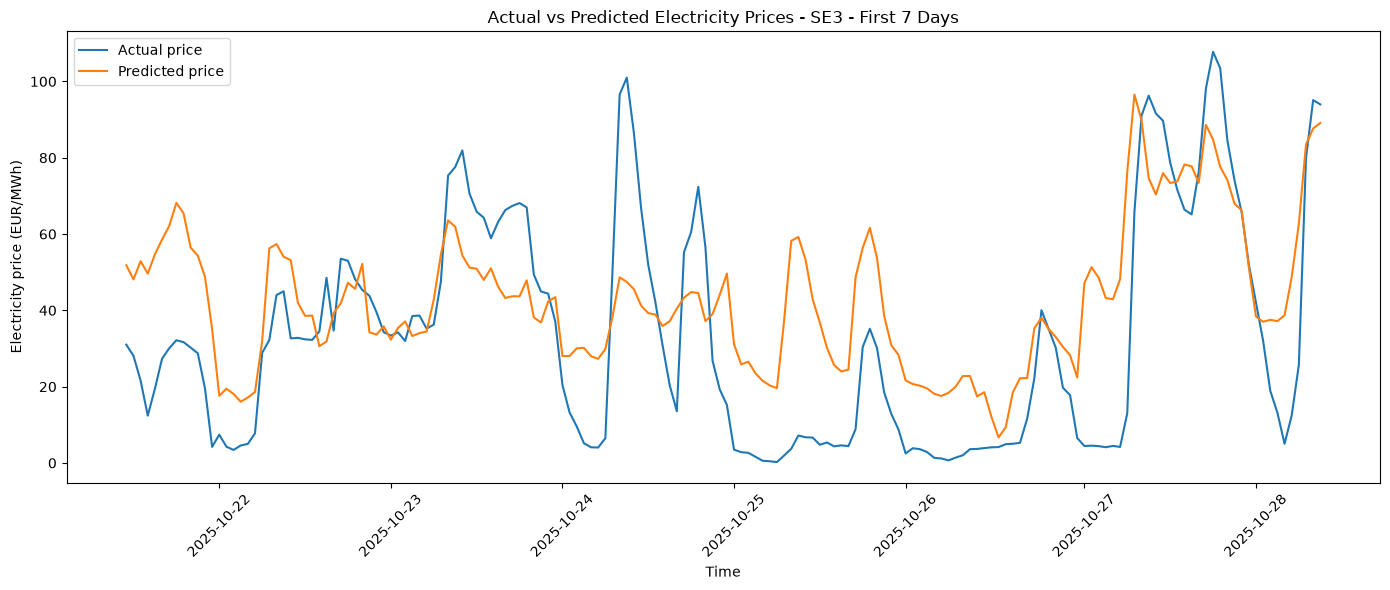

In [88]:
# Show actual vs predicted prices for the first 7 days in SE3.
first_week = (
    results[results["zone"] == "SE3"]
    .sort_values("timestamp")
    .iloc[:24 * 7]
)

plt.figure(figsize=(14, 6))

plt.plot(
    first_week["timestamp"],
    first_week["actual"],
    label="Actual price"
)

plt.plot(
    first_week["timestamp"],
    first_week["predicted"],
    label="Predicted price"
)

plt.xlabel("Time")
plt.ylabel("Electricity price (EUR/MWh)")
plt.title("Actual vs Predicted Electricity Prices - SE3 - First 7 Days")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [89]:
# Rank features by how much the tuned model used them.
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,feature,importance
0,price_lag_24,0.325851
1,price_lag_48,0.154658
2,price_lag_168,0.128349
3,wind_speed_kmh,0.083394
4,temperature_c,0.059976
5,day_of_week,0.052376
6,zone_SE4,0.048344
7,month,0.044749
8,hour,0.040449
9,is_weekend,0.020580


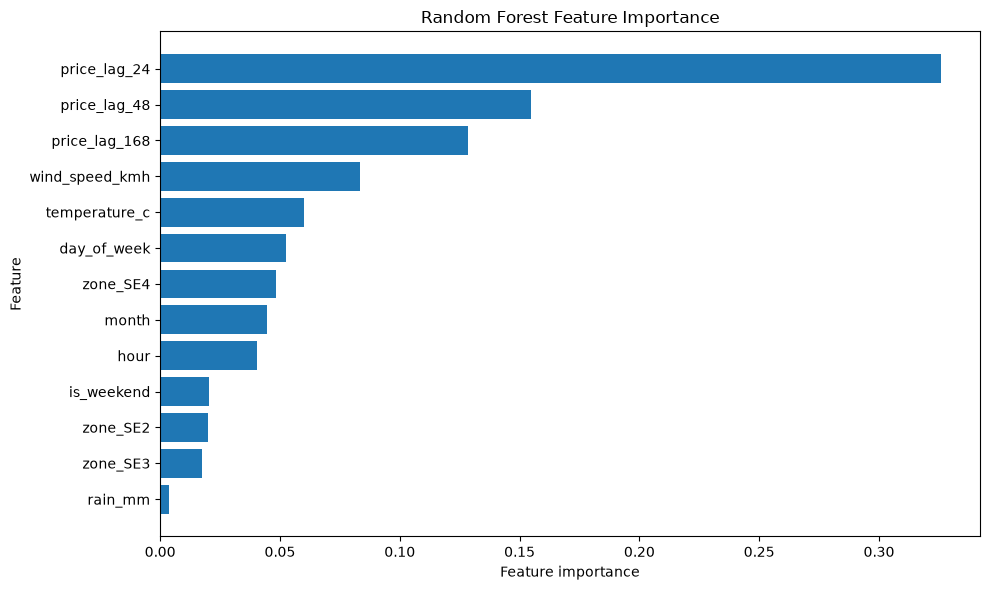

In [90]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

### Feature importance observations

The price 24 hours earlier is the most important feature. Other past prices, temperature, wind speed, and time features also help.

What's interesting is that the model seems to be using wich zone the observation belongs to.

Feature importance shows what the model uses. It does not show what causes price changes.

In [91]:
# Calculate signed and absolute prediction errors.
results["error"] = results["actual"] - results["predicted"]
results["absolute_error"] = results["error"].abs()

In [92]:
# Show the ten test observations with the largest prediction errors.
largest_errors = (
    results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

largest_errors

,timestamp,zone,actual,predicted,error,absolute_error
6000,2025-11-25 13:00:00+01:00,SE4,340.32,135.671996,204.648004,204.648004
5999,2025-11-25 12:00:00+01:00,SE4,332.06,146.816823,185.243177,185.243177
5995,2025-11-25 08:00:00+01:00,SE4,328.99,145.324441,183.665559,183.665559
2470,2025-11-21 17:00:00+01:00,SE2,243.89,60.639624,183.250376,183.250376
6004,2025-11-25 17:00:00+01:00,SE4,366.85,191.229978,175.620022,175.620022
5981,2025-11-24 18:00:00+01:00,SE4,276.33,106.670974,169.659026,169.659026
2461,2025-11-21 08:00:00+01:00,SE2,221.99,54.110070,167.879930,167.879930
5997,2025-11-25 10:00:00+01:00,SE4,328.77,162.301483,166.468517,166.468517
4281,2025-11-25 13:00:00+01:00,SE3,293.90,128.012329,165.887671,165.887671
5996,2025-11-25 09:00:00+01:00,SE4,314.62,149.296440,165.323560,165.323560


## Error analysis

The biggest errors happen when prices change quickly or unusually.

The model follows normal patterns better than rare events. Missing factors, such as demand and generation, may explain these errors.

In [94]:
# Calculate the average absolute error for each hour of the day.
# Not grouped by zone to understand which hours in a day the model has a har time to predict SE1 - SE4 in general
results["hour"] = results["timestamp"].dt.hour

error_by_hour = (
    results
    .groupby("hour")["absolute_error"]
    .mean()
)

error_by_hour

hour
0     17.146024
1     15.375940
2     14.146752
3     14.015392
4     13.901109
5     13.882629
6     15.522507
7     19.905116
8     25.319153
9     27.296682
10    24.711876
11    22.892646
12    21.783203
13    21.840152
14    21.421680
15    23.605628
16    26.875146
17    30.208676
18    28.254028
19    26.187296
20    23.155970
21    19.847849
22    19.203964
23    17.101105
Name: absolute_error, dtype: float64

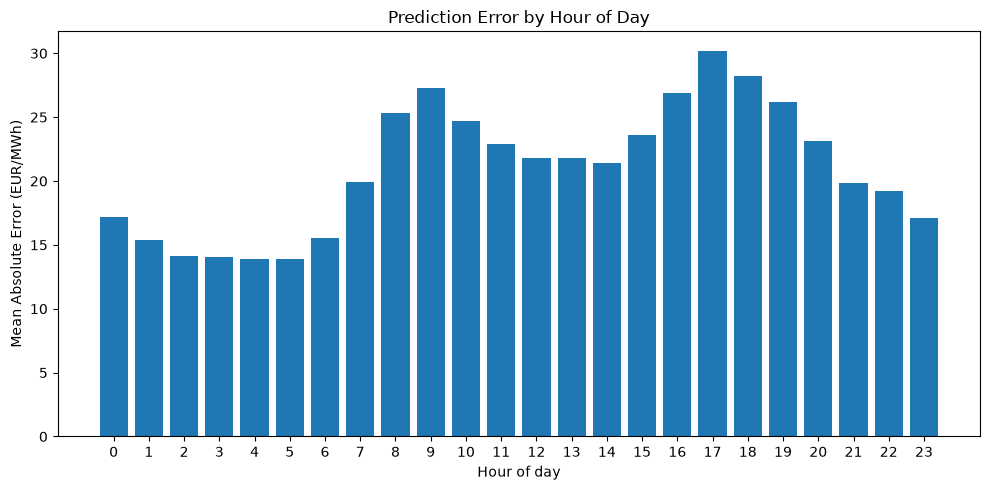

In [95]:
plt.figure(figsize=(10, 5))

plt.bar(
    error_by_hour.index,
    error_by_hour.values
)

plt.xlabel("Hour of day")
plt.ylabel("Mean Absolute Error (EUR/MWh)")
plt.title("Prediction Error by Hour of Day")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

# Model comparison

In [101]:
# Compare all models against the naive 24-hour baseline.
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline (24h)",
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        tuned_rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        tuned_rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        tuned_rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Naive Baseline (24h),26.411947,39.467793,0.219476
1,Linear Regression,24.129843,32.013746,0.486461
2,Random Forest,22.477590,31.796119,0.493419
3,Tuned Random Forest,20.994361,30.115840,0.545546


The Tuned Random Forest achieved the best performance on the unseen test data, with an MAE of 20.99 EUR/MWh compared with 26.41 EUR/MWh for the naive 24-hour baseline. It also achieved the lowest RMSE and highest R² among the evaluated models. Therefore, the Tuned Random Forest was selected as the final regression model.

# Save model

In [96]:
model_dir = Path("../models_bin")
model_dir.mkdir(exist_ok=True)

In [ ]:
# Save the trained model together with the feature list it expects.
model_package = {
    "model": best_rf,
    "features": features
}

model_path = model_dir / "random_forest_all_zones.joblib"

joblib.dump(model_package, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models_bin\random_forest_se3.joblib
